<a href="https://colab.research.google.com/github/ced-sys/AI-N-ML/blob/main/Random_Forest_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import(classification_report, confusion_matrix, accuracy_score, precision_score,
                            recall_score, f1_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
def generate_spam_dataset(n_samples=2000, random_state=42):
  np.random.seed(random_state)

  #Initialize lists to store features and labels
  features=[]
  labels=[]

  for i in range(n_samples):
    #Determine if email is spam (40% spam rate)
    is_spam=np.random.random()<0.4

    if is_spam:
      #Spam characteristics
      word_count=np.random.normal(150, 50) #longer emails
      capital_ratio=np.random.beta(3, 2)*50 #More capitals
      exclamation_count=np.random.poisson(4)+1 #more exclamations
      url_count=np.random.poisson(2)+1 #more URLs
      special_char_ratio=np.random.beta(2, 3)* 30 #More special chars
      digit_ratio=np.random.beta(2, 3)* 25 #more digits
      avg_word_length=np.random.normal(4.5, 1) #Shorter words
      sentence_count=np.random.poisson(8)+3 #More sentences
    else:
      #Ham (legitimate email) characteristics
      word_count=np.random.normal(100, 40) #Shorter emails
      capital_ratio=np.random.beta(1, 4)*15 #Fewer capitals
      exclamation_count=np.random.poisson(0.5) #Fewer exclamations
      url_count=np.random.poisson(0.3) #Fewer URLs
      special_char_ratio=np.random.beta(1, 4)*10 #Fewer special chars
      digit_ratio=np.random.beta(1, 3)*15 #Fewer digits
      avg_word_length=np.random.normal(5.2, 0.8) #Longer words
      sentence_count=np.random.poisson(5)+2 #Fewer sentences

    #Ensure realistic bounds
    word_count=max(10, word_count)
    capital_ratio=np.clip(capital_ratio, 0, 100)
    exclamation_count=max(0, exclamation_count)
    url_count=max(0, url_count)
    special_char_ratio=np.clip(special_char_ratio, 0, 100)
    digit_ratio=np.clip(digit_ratio, 0, 100)
    avg_word_length=np.clip(avg_word_length, 2, 15)
    sentence_count=max(1, sentence_count)

    features.append([
        word_count, capital_ratio, exclamation_count, url_count,
        special_char_ratio, digit_ratio, avg_word_length, sentence_count
    ])
    labels.append(1 if is_spam else 0)

  #Create DataFrame
  feature_names=[
      'word_count', 'capital_ratio', 'exclamation_count', 'url_count',
      'special_char_ratio', 'digit_ratio', 'avg_word_length', 'sentence_count'
  ]

  df=pd.DataFrame(features, columns=feature_names)
  df['is_spam']=labels

  return df


In [ ]:
print("Generating spam dataset...")
df=generate_spam_dataset(n_samples=2000)
print("Dataset created with {len(df)} samples")
print(f"Spam rate: {df['is_spam'].mean():.1%}")

print("\n First 5 rows of the dataset:")
df.head()

Generating spam dataset...
Dataset created with {len(df)} samples
Spam rate: 40.1%

 First 5 rows of the dataset:


,word_count,capital_ratio,exclamation_count,url_count,special_char_ratio,digit_ratio,avg_word_length,sentence_count,is_spam
0,94.405994,20.465932,5,3,20.487184,6.620101,4.274224,8,1
1,75.974452,4.031774,0,0,0.106701,1.503050,4.137451,9,0
2,159.843062,39.746444,4,2,10.979089,11.090095,2.991847,10,1
3,143.985879,2.446308,0,0,0.058800,0.484837,6.033993,7,0
4,175.072417,41.230643,5,2,27.128912,9.562667,4.333939,12,1


In [ ]:
print("\n"+"="*50)
print("EDA")
print("="*50)

print("\nDataset Summary:")
print(df.describe())

print(f"\nClass Distribution:")
print(f"Ham (legitimate): {(df['is_spam']==0).sum()} ({(df['is_spam']==0).mean():.1%})")
print(f"Spam: {(df['is_spam']==1).sum()} ({(df['is_spam']==1).mean():.1%})")


EDA

Dataset Summary:
        word_count  capital_ratio  exclamation_count    url_count  \
count  2000.000000    2000.000000        2000.000000  2000.000000   
mean    118.095351      13.795597           2.314000     1.378500   
std      49.298468      14.955045           2.644598     1.683049   
min      10.000000       0.001451           0.000000     0.000000   
25%      83.892565       1.747425           0.000000     0.000000   
50%     115.569356       5.265835           1.000000     1.000000   
75%     150.926069      26.821932           4.000000     2.000000   
max     296.483884      49.176431          13.000000    11.000000   

       special_char_ratio  digit_ratio  avg_word_length  sentence_count  \
count         2000.000000  2000.000000      2000.000000     2000.000000   
mean             5.914114     6.193732         4.947229        8.600500   
std              6.223358     4.804760         0.931158        3.202972   
min              0.000518     0.000257         2.000000

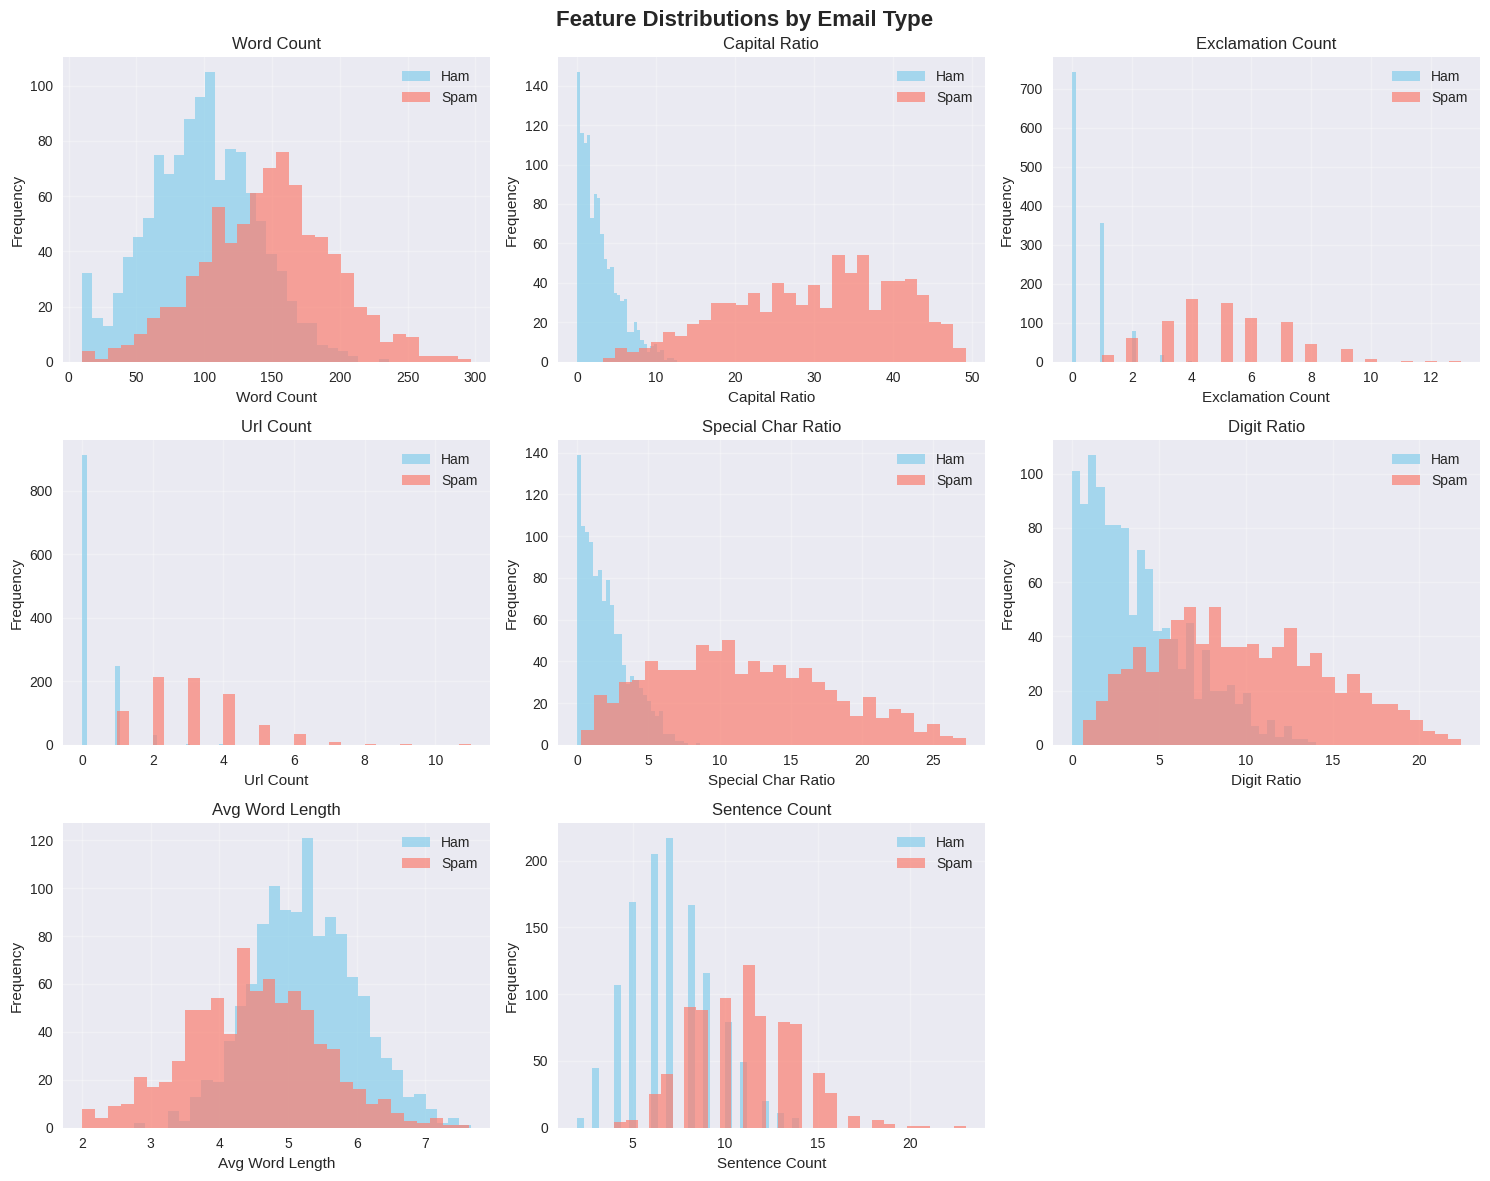

In [ ]:
fig, axes=plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions by Email Type', fontsize=16, fontweight='bold')

features_to_plot=[col for col in df.columns if col != 'is_spam']
axes=axes.flatten()

for i, feature in enumerate(features_to_plot):
  if i<len(axes):
    #Create histogram for spam vs ham
    spam_data=df[df['is_spam']==1][feature]
    ham_data=df[df['is_spam']==0][feature]

    axes[i].hist(ham_data, alpha=0.7, label="Ham", bins=30, color='skyblue')
    axes[i].hist(spam_data, alpha=0.7, label='Spam', bins=30, color='salmon')
    axes[i].set_title(f'{feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

if len(features_to_plot)<len(axes):
  fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

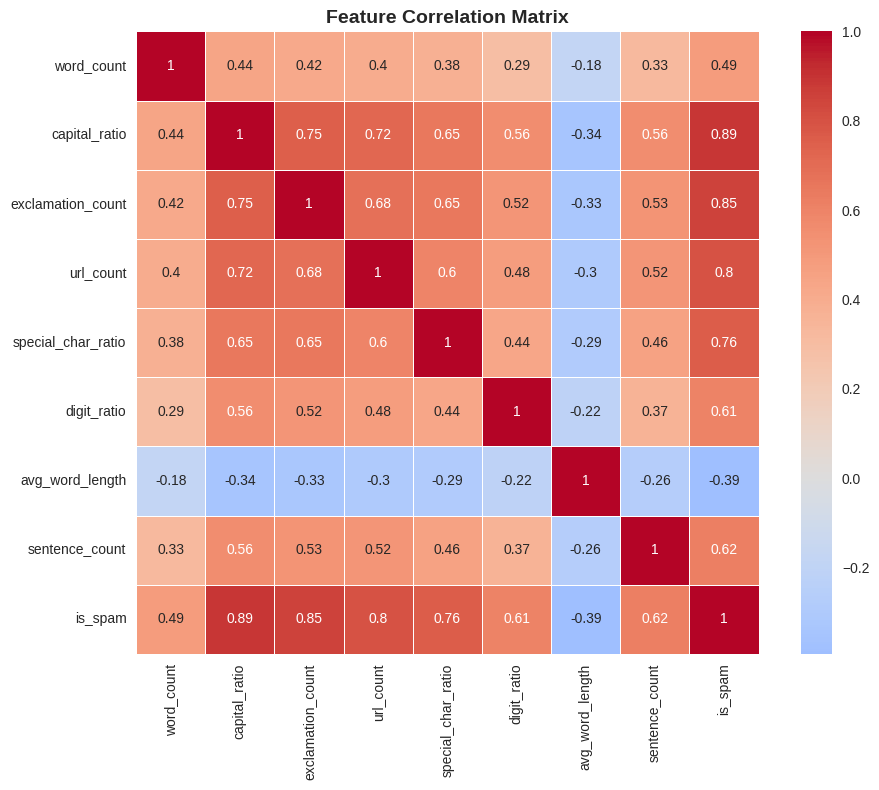

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix=df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidth=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n"+"="*50)
print("MODEL PREPARATION")
print("="*50)

#Separate features and target
X=df.drop('is_spam', axis=1)
y=df['is_spam']

print(f"Feature Matrix shape: {X.shape}")
print(f"Target Vector shape: {y.shape}")

#Split the data
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

#Feature scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("Data preprocessing completed!")


MODEL PREPARATION
Feature Matrix shape: (2000, 8)
Target Vector shape: (2000,)

Training set: 1600 samples
Test set: 400 samples
Data preprocessing completed!


In [ ]:
print("\n"+"="*50)
print("RANDOM FOREST TRAINING")
print("="*50)

#Initialize Random Forest with good default parameters
rf_model=RandomForestClassifier(
    n_estimators=106, #Number of trees
    max_depth=10, #Maximum depth of trees
    min_samples_split=5, #Minimum samples to split a node
    min_samples_leaf=2, #minimum samples in a leaf
    max_features='sqrt', #Number of features to consider for best split
    random_state=42,
    n_jobs=-1
)

print("training Random Forest Model...")
rf_model.fit(X_train, y_train)
print("Model training completed!")

#make predictions
print("Making predictions...")
y_train_pred=rf_model.predict(X_train)
y_test_pred=rf_model.predict(X_test)
y_test_proba=rf_model.predict_proba(X_test)[:, 1] #Probability of spam
print("Prediction completed!")


RANDOM FOREST TRAINING
training Random Forest Model...
Model training completed!
Making predictions...
Prediction completed!


In [ ]:
print("\n"+ "="*50)
print("Model Evaluation")
print("="*50)

#Calculate metrics
train_accuracy=accuracy_score(y_train, y_train_pred)
test_accuracy=accuracy_score(y_test, y_test_pred)
precision=precision_score(y_test, y_test_pred)
recall=recall_score(y_test, y_test_pred)
f1=f1_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy:{test_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

#Check for overfitting
if train_accuracy-test_accuracy>0.05:
  print("Warning: Possible overfitting detected")
else:
  print("Model generalization looks good")

print(f"\n Detailed Classification report:")
print(classification_report(y_test, y_test_pred,
                            target_names=["Ham", "Spam"]))




Model Evaluation
Training Accuracy: 1.000
Test Accuracy:1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000
Model generalization looks good

 Detailed Classification report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       240
        Spam       1.00      1.00      1.00       160

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
print("\n"+"="*50)
print("VISUALIZATION OF RESULTS")
print("="*50)

#Create a comprehensive visualization
fig, axes=plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Spam Detection Model Results', fontsize=16, fontweight='bold')

#Confusion matrix
cm=confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham','Spam'],
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

#2. Feature Importance
feature_importance=pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0, 1].barh(feature_importance['feature'], feature_importance['importance'])
axes[0, 1].set_title('Feature Importance')
axes[0, 1].set_xlabel('Importance')

#ROC Curve
fpr,tpr, _=roc_curve(y_test, t_test_proba)
roc_auc=auc(fpr, tpr)
axes[0, 2].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC={roc_auc:.2f})')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].set_title('ROC Curve')
axes[0, 2].legend(loc="lower right")

#4.Precision-Recall Curve
precision_vals, recall_vals, _=precision_recall_curve(y_test, y_test_proba)
pr_auc=auc(recall_vals, precision_vals)
axes[1, 0].plot(recall_vals, precision_vals, color='blue', lw=2,
                label=f"PR Curve(AUC= {pr_auc:.2f})")
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()